In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from fixation_prediction.data.utils import list_salicon_image_ids

ids = list_salicon_image_ids("D:/datasets/salicon/images", "train")
len(ids)
print(ids[10])

In [ ]:
from fixation_prediction.data.utils import load_salicon_fixations

# Pick the first training image
img_id = ids[0]
mat_path = f"D:/datasets/salicon/fixations/train/{img_id}.mat"

fixations, image_size = load_salicon_fixations(mat_path)
fixations.shape, image_size

In [ ]:
from fixation_prediction.data.utils import fixations_to_density_map

density = fixations_to_density_map(fixations, image_size, sigma=19.0)
density.shape, density.sum(), density.dtype

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(density, cmap="hot")
plt.colorbar()
plt.title(f"Density map for {img_id}")
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image
import numpy as np

salicon_map = np.asarray(Image.open(f"D:/datasets/salicon/maps/train/{img_id}.png"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(density, cmap="hot")
axes[0].set_title("Our density map (from .mat fixations)")
axes[0].axis("off")
axes[1].imshow(salicon_map, cmap="hot")
axes[1].set_title("SALICON's pre-computed map")
axes[1].axis("off")
plt.show()

In [ ]:
image = np.asarray(Image.open(f"D:/datasets/salicon/images/train/{img_id}.jpg"))

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.imshow(density, cmap="hot", alpha=0.5)  # alpha = transparency
plt.title("Image with attention heatmap overlay")
plt.axis("off")
plt.show()

In [ ]:
from pathlib import Path
from scipy.io import loadmat

# How many .mat files in test?
test_mat_dir = Path("D:/datasets/salicon/fixations/test")
test_mats = sorted(test_mat_dir.glob("*.mat"))
print(f"Test .mat files: {len(test_mats)}")

# Load one and inspect
sample = loadmat(str(test_mats[0]))
print(f"Keys: {[k for k in sample.keys() if not k.startswith('__')]}")
if 'gaze' in sample:
    gaze = sample['gaze']
    print(f"Workers: {gaze.shape[0]}")
    fixations = gaze[0, 0]['fixations']
    print(f"First worker's fixations: shape={fixations.shape}")
maps_test = Path("D:/datasets/salicon/maps/test")
print(f"Maps test exists: {maps_test.exists()}")
if maps_test.exists():
    pngs = sorted(maps_test.glob("*.png"))
    print(f"PNG files in maps/test: {len(pngs)}")

In [1]:
from fixation_prediction.data.salicon import SaliconDataset

ds = SaliconDataset(
    root="D:/datasets/salicon",
    split="train",
    image_size=(256, 256),
)
sample = ds[0]
print("Keys:", list(sample.keys()))
print(f"image:     shape={sample['image'].shape}, dtype={sample['image'].dtype}")
print(f"saliency:  shape={sample['saliency'].shape}, dtype={sample['saliency'].dtype}, sum={sample['saliency'].sum():.4f}")
print(f"fixations: shape={sample['fixations'].shape}, dtype={sample['fixations'].dtype}")
print(f"image_id:  {sample['image_id']}")

Keys: ['image', 'saliency', 'fixations', 'image_id']
image:     shape=torch.Size([3, 256, 256]), dtype=torch.float32
saliency:  shape=torch.Size([1, 256, 256]), dtype=torch.float32, sum=1.0000
fixations: shape=torch.Size([532, 2]), dtype=torch.int32
image_id:  COCO_train2014_000000000009


In [ ]:
print(f"image range:    [{sample['image'].min():.3f}, {sample['image'].max():.3f}]")
print(f"saliency range: [{sample['saliency'].min():.6f}, {sample['saliency'].max():.6f}]")
print(f"fixations x range: [{sample['fixations'][:, 0].min()}, {sample['fixations'][:, 0].max()}]")
print(f"fixations y range: [{sample['fixations'][:, 1].min()}, {sample['fixations'][:, 1].max()}]")

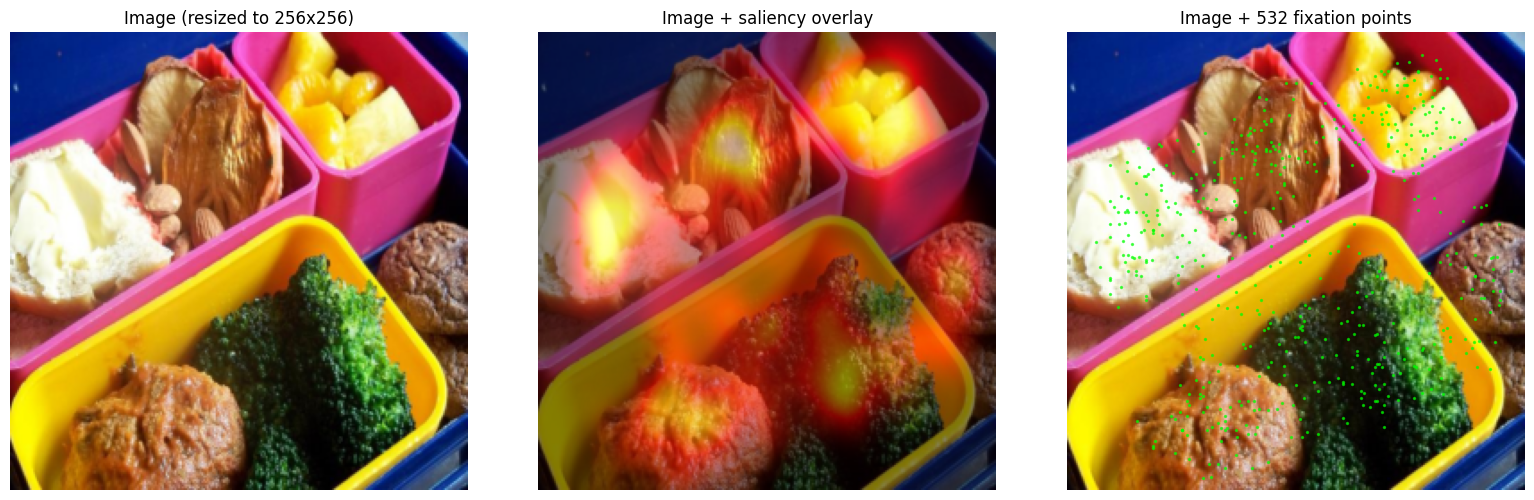

Image ID: COCO_train2014_000000000009


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a sample
sample = ds[0]
image = sample["image"].permute(1, 2, 0).numpy()  # back to (H, W, 3) for matplotlib
saliency = sample["saliency"].squeeze(0).numpy()   # drop channel dim
fixations = sample["fixations"].numpy()

# Three-panel figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(image)
axes[0].set_title("Image (resized to 256x256)")
axes[0].axis("off")

axes[1].imshow(image)
axes[1].imshow(saliency, cmap="hot", alpha=0.5)
axes[1].set_title("Image + saliency overlay")
axes[1].axis("off")

axes[2].imshow(image)
axes[2].scatter(fixations[:, 0], fixations[:, 1], s=2, c="lime", alpha=0.6)
axes[2].set_title(f"Image + {len(fixations)} fixation points")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Image ID: {sample['image_id']}")

In [ ]:
for idx in [100, 500, 1000, 5000]:
    sample = ds[idx]
    image = sample["image"].permute(1, 2, 0).numpy()
    saliency = sample["saliency"].squeeze(0).numpy()
    fixations = sample["fixations"].numpy()

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.imshow(image)
    ax.imshow(saliency, cmap="hot", alpha=0.5)
    ax.scatter(fixations[:, 0], fixations[:, 1], s=2, c="lime", alpha=0.6)
    ax.set_title(f"idx={idx}, {sample['image_id']}, {len(fixations)} fix")
    ax.axis("off")
    plt.show()

In [2]:
from torch.utils.data import DataLoader
from fixation_prediction.data.salicon import salicon_collate
from fixation_prediction.data.salicon import SaliconDataset

ds = SaliconDataset(
    root="D:/datasets/salicon",
    split="train",
    image_size=(256, 256),
)
# Wrap the existing dataset in a DataLoader
loader = DataLoader(
    ds,
    batch_size=4,
    shuffle=False,           # deterministic for testing
    num_workers=0,           # single-process for now (Windows safety)
    collate_fn=salicon_collate,
)

# Pull one batch
batch = next(iter(loader))

print(f"image:     {batch['image'].shape}")
print(f"saliency:  {batch['saliency'].shape}")
print(f"image_ids: {batch['image_id']}")
print(f"Number of fixation tensors in batch: {len(batch['fixations'])}")
for i, fix in enumerate(batch["fixations"]):
    print(f"  Sample {i}: {fix.shape[0]} fixations")

image:     torch.Size([4, 3, 256, 256])
saliency:  torch.Size([4, 1, 256, 256])
image_ids: ['COCO_train2014_000000000009', 'COCO_train2014_000000000089', 'COCO_train2014_000000000110', 'COCO_train2014_000000000307']
Number of fixation tensors in batch: 4
  Sample 0: 532 fixations
  Sample 1: 528 fixations
  Sample 2: 370 fixations
  Sample 3: 279 fixations
